In [ ]:
pip install numpy pandas matplotlib seaborn scikit-learn tensorflow gensim nltk contractions wordcloud streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 52.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 61.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 70.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 9.4 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!python sms_spam_complete.py

python3: can't open file '/content/sms_spam_complete.py': [Errno 2] No such file or directory


In [ ]:
!python -m streamlit run sms_spam_complete.py

Usage: streamlit run [OPTIONS] [TARGET] [ARGS]...
Try 'streamlit run --help' for help.

Error: Invalid value: File does not exist: sms_spam_complete.py


In [ ]:
import sys
_STREAMLIT_MODE = "streamlit" in sys.modules or any(
    "streamlit" in a for a in sys.argv
)

In [ ]:
import re
import os
import pickle
import warnings
warnings.filterwarnings("ignore")

In [ ]:
import numpy as np
import pandas as pd
import matplotlib
if not _STREAMLIT_MODE:
    matplotlib.use("Agg")          # change to "Agg" if no display
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

In [ ]:
import nltk
for pkg in ("stopwords", "wordnet", "omw-1.4"):
    nltk.download(pkg, quiet=True)
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [ ]:
import contractions as ctr

from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report)

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Embedding, SimpleRNN, LSTM,
                                     Dense, Dropout)
from tensorflow.keras.callbacks import EarlyStopping

from gensim.models import Word2Vec

In [ ]:
# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

After uploading the `spamvsham.csv` file to `/content/`, the `DATASET_PATH` will be updated to reflect this location. You can verify the file is present using `!ls /content/`.

In [ ]:
from google.colab import files
import os

# Check if the file already exists before prompting for upload
if not os.path.exists('/content/spamvsham.csv'):
    print("Please upload the 'spamvsham.csv' file. A file selection dialog should appear.")
    print("If it doesn't appear, please check your browser or Colab settings for pop-up blockers.")
    uploaded = files.upload()
    if not uploaded:
        print("No file was uploaded. Please try again and select 'spamvsham.csv'.")
    for fn in uploaded.keys():
        print('User uploaded file "{name}" with length {length} bytes'.format(
            name=fn, length=len(uploaded[fn])))
else:
    print("File 'spamvsham.csv' already exists. Skipping upload.")

Please upload the 'spamvsham.csv' file. A file selection dialog should appear.
If it doesn't appear, please check your browser or Colab settings for pop-up blockers.


No file was uploaded. Please try again and select 'spamvsham.csv'.


In [ ]:
DATASET_PATH = "/content/drive/MyDrive/9.Spam vs Ham Sms Dataset/spamvsham.csv"   # File path after direct upload

df = pd.read_csv(
    DATASET_PATH,
    sep=",",  # Corrected separator from tab to comma
    header=None,
    names=["label", "text"],
    encoding="latin-1",
    usecols=[0, 1]  # Ensure only the first two columns are read
)

In [ ]:
DATASET_PATH = "/content/drive/MyDrive/9.Spam vs Ham Sms Dataset/spamvsham.csv"   # File path after direct upload

df = pd.read_csv(
    DATASET_PATH,
    sep=",",  # Corrected separator from tab to comma
    header=None,
    names=["label", "text"],
    encoding="latin-1",
    usecols=[0, 1]  # Ensure only the first two columns are read
)

In [ ]:
print(df.head(8).to_string())
print(f"\nShape        : {df.shape}")
print(f"Label counts :\n{df['label'].value_counts()}")

  label                                                                                                                                                         text
0    v1                                                                                                                                                           v2
1   ham                                              Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...
2   ham                                                                                                                                Ok lar... Joking wif u oni...
3  spam  Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's
4   ham                                                                                                            U dun say so early hor... U c already then say...
5   ham   

In [ ]:
# Binary encoding  ham=0  spam=1
df["label_enc"] = df["label"].map({"ham": 0, "spam": 1})

Text Cleanning

In [ ]:
STOP_WORDS = set(stopwords.words("english"))
LEMMATIZER = WordNetLemmatizer()

In [ ]:
def clean_text(raw: str) -> str:
    """Full NLP pre-processing pipeline."""
    text = ctr.fix(raw)                         # expand contractions
    text = text.lower()                         # lowercase
    text = re.sub(r"https?://\S+|www\.\S+", "", text)  # URLs
    text = re.sub(r"#\w+", "", text)            # #hashtags
    text = re.sub(r"\d+", "", text)             # numbers
    text = re.sub(r"[^a-z\s]", "", text)        # special chars
    tokens = text.split()
    tokens = [LEMMATIZER.lemmatize(w)
              for w in tokens if w not in STOP_WORDS]
    return " ".join(tokens)

In [ ]:
df["clean_text"] = df["text"].apply(clean_text)
print(df[["label", "text", "clean_text"]].head(6).to_string())

  label                                                                                                                                                         text                                                                                                  clean_text
0    v1                                                                                                                                                           v2                                                                                                           v
1   ham                                              Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...                          go jurong point crazy available bugis n great world la e buffet cine got amore wat
2   ham                                                                                                                                Ok lar... Joking wif u oni...                 

Visualize:Word Clouds and Freq Words


[Plotting word clouds …]


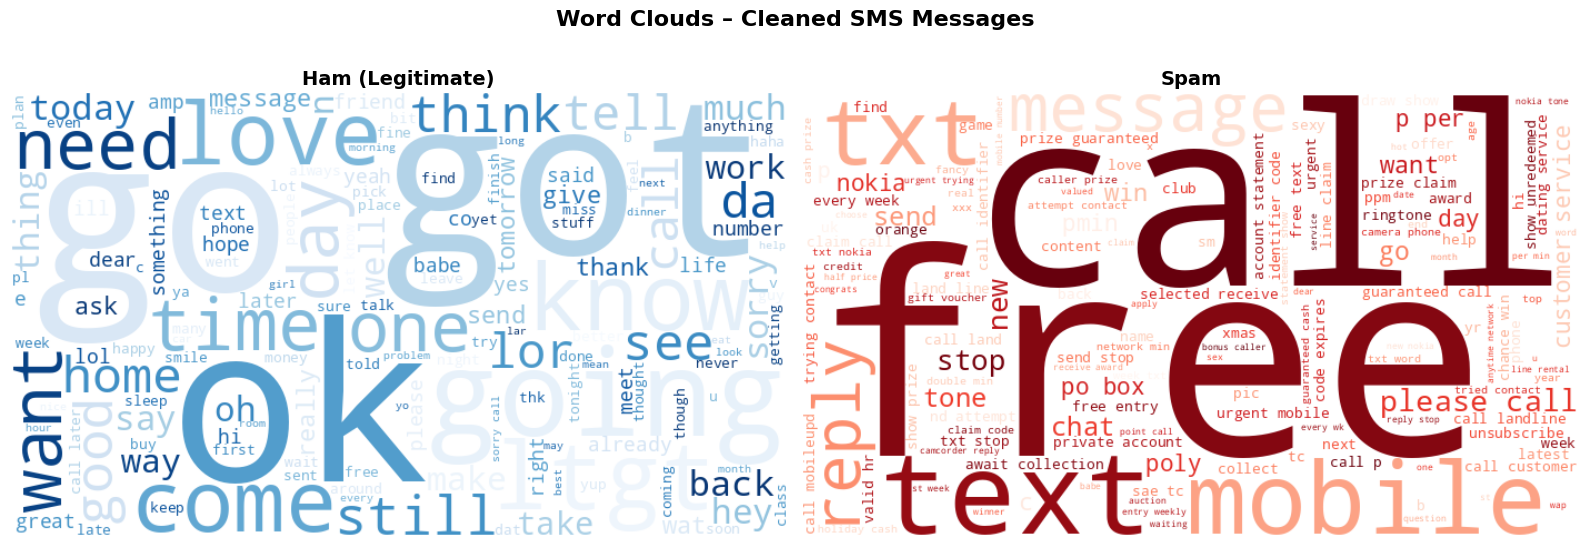

In [ ]:
print("\n[Plotting word clouds …]")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Word Clouds – Cleaned SMS Messages", fontsize=16, fontweight="bold")

for ax, lbl, cmap in zip(axes, ["ham", "spam"], ["Blues", "Reds"]):
    corpus = " ".join(df[df["label"] == lbl]["clean_text"])
    wc = WordCloud(width=700, height=400, colormap=cmap,
                   background_color="white", max_words=150).generate(corpus)
    ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    ax.set_title("Ham (Legitimate)" if lbl == "ham" else "Spam",
                 fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()
display(fig)

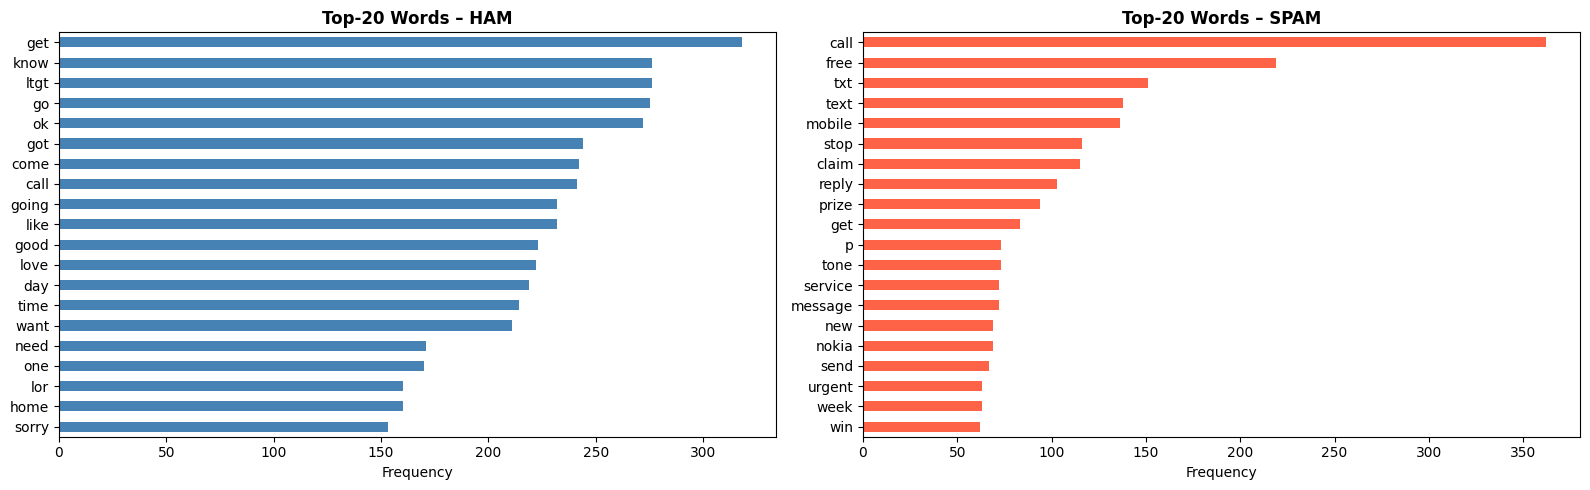

In [ ]:
# Top-20 words per class
fig2, axes2 = plt.subplots(1, 2, figsize=(16, 5))
for ax, lbl, colour in zip(axes2, ["ham", "spam"], ["steelblue", "tomato"]):
    freq = (pd.Series(" ".join(df[df["label"] == lbl]["clean_text"]).split())
            .value_counts().head(20))
    freq.sort_values().plot(kind="barh", ax=ax, color=colour)
    ax.set_title(f"Top-20 Words – {lbl.upper()}", fontweight="bold")
    ax.set_xlabel("Frequency")

plt.tight_layout()
plt.show()
display(fig2)

Training/testing

In [ ]:
df_cleaned = df[df['label'] != 'v1'].copy() # Filter out the header row 'v1'

X = df_cleaned["clean_text"].values
y = df_cleaned["label_enc"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f"\nTrain : {len(X_train)} samples | Test : {len(X_test)} samples")


Train : 4457 samples | Test : 1115 samples


Tokenization

In [ ]:
VOCAB_SIZE = 10_000

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

train_seq = tokenizer.texts_to_sequences(X_train)
test_seq  = tokenizer.texts_to_sequences(X_test)

print(f"Vocabulary size (actual): {len(tokenizer.word_index)}")

Vocabulary size (actual): 6876


Padding

In [ ]:
lengths = [len(s) for s in train_seq]
MAX_LEN = int(np.percentile(lengths, 95))
print(f"Max sequence length (95th percentile): {MAX_LEN}")

X_train_pad = pad_sequences(train_seq, maxlen=MAX_LEN,
                             padding="post", truncating="post")
X_test_pad  = pad_sequences(test_seq,  maxlen=MAX_LEN,
                             padding="post", truncating="post")

print(f"X_train_pad : {X_train_pad.shape}")
print(f"X_test_pad  : {X_test_pad.shape}")

Max sequence length (95th percentile): 18
X_train_pad : (4457, 18)
X_test_pad  : (1115, 18)


Model Building

In [ ]:
EMBED_DIM  = 64
UNITS      = 64
EPOCHS     = 20
BATCH_SIZE = 64

early_stop = EarlyStopping(monitor="val_loss", patience=3,
                           restore_best_weights=True, verbose=1)

RNN

In [ ]:
model1 = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM, input_length=MAX_LEN),
    SimpleRNN(UNITS),
    Dropout(0.3),
    Dense(32, activation="relu"),
    Dense(1, activation="sigmoid")
], name="Model1_SimpleRNN")

model1.compile(optimizer="adam",
               loss="binary_crossentropy",
               metrics=["accuracy"])

model1.build(input_shape=(None, MAX_LEN))
model1.summary()

Model: "Model1_SimpleRNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 18, 64)         │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 650,369 (2.48 MB)

 Trainable params: 650,369 (2.48 MB)

 Non-trainable params: 0 (0.00 B)

LSTM + Trainable Embeddings

In [ ]:
model2 = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM, input_length=MAX_LEN),
    LSTM(UNITS),
    Dropout(0.3),
    Dense(32, activation="relu"),
    Dense(1,  activation="sigmoid")
], name="Model2_LSTM_Trainable")

model2.compile(optimizer="adam",
               loss="binary_crossentropy",
               metrics=["accuracy"])

model2.build(input_shape=(None, MAX_LEN))
model2.summary()

Model: "Model2_LSTM_Trainable"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 18, 64)         │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 675,137 (2.58 MB)

 Trainable params: 675,137 (2.58 MB)

 Non-trainable params: 0 (0.00 B)

LSTM + Word2Vec Embeddings

In [ ]:
# First, train a Word2Vec model
word2vec_model = Word2Vec(sentences=df_cleaned['clean_text'].apply(str.split), # Using split words from clean_text
                          vector_size=EMBED_DIM,
                          window=5,
                          min_count=1,
                          workers=4)

# Create an embedding matrix
embedding_matrix = np.zeros((VOCAB_SIZE, EMBED_DIM))
for word, i in tokenizer.word_index.items():
    if i < VOCAB_SIZE:
        if word in word2vec_model.wv:
            embedding_matrix[i] = word2vec_model.wv[word]
        else:
            # For words not in Word2Vec, initialize with random vectors
            embedding_matrix[i] = np.random.normal(size=(EMBED_DIM,))

model3 = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM,
              weights=[embedding_matrix],
              input_length=MAX_LEN,
              trainable=True),
    LSTM(UNITS),
    Dropout(0.3),
    Dense(32, activation="relu"),
    Dense(1, activation="sigmoid")
], name="Model3_LSTM_Word2Vec")

model3.compile(optimizer="adam",
               loss="binary_crossentropy",
               metrics=["accuracy"])

model3.build(input_shape=(None, MAX_LEN))
model3.summary()

Model: "Model3_LSTM_Word2Vec"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 18, 64)         │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 675,137 (2.58 MB)

 Trainable params: 675,137 (2.58 MB)

 Non-trainable params: 0 (0.00 B)

Trainning and Evaluation

In [ ]:
def train_model(model, label):
    print(f"\n{'='*55}\n  Training: {label}\n{'='*55}")
    history = model.fit(
        X_train_pad, y_train,
        validation_split=0.10,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[early_stop],
        verbose=1
    )
    return history


hist1 = train_model(model1, "Model 1 – Simple RNN")
hist2 = train_model(model2, "Model 2 – LSTM Trainable Emb")
hist3 = train_model(model3, "Model 3 – LSTM Word2Vec Emb")


  Training: Model 1 – Simple RNN
Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 57ms/step - accuracy: 0.9210 - loss: 0.2316 - val_accuracy: 0.9619 - val_loss: 0.1367
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9865 - loss: 0.0569 - val_accuracy: 0.9664 - val_loss: 0.1125
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9963 - loss: 0.0202 - val_accuracy: 0.9753 - val_loss: 0.1064
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9965 - loss: 0.0163 - val_accuracy: 0.9776 - val_loss: 0.0942
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9970 - loss: 0.0157 - val_accuracy: 0.9753 - val_loss: 0.0916
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9988 - loss: 0.0063 - val_accuracy: 0.9776 - val_loss: 0.1188
Epoch 7/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9913 - loss: 0.0402 - val_accuracy: 0.9686 - val_loss: 0.1410
Epoch 8/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9958 - loss: 0.0202

Trainning us Validations Curves

In [ ]:
%matplotlib inline

Simple RNN

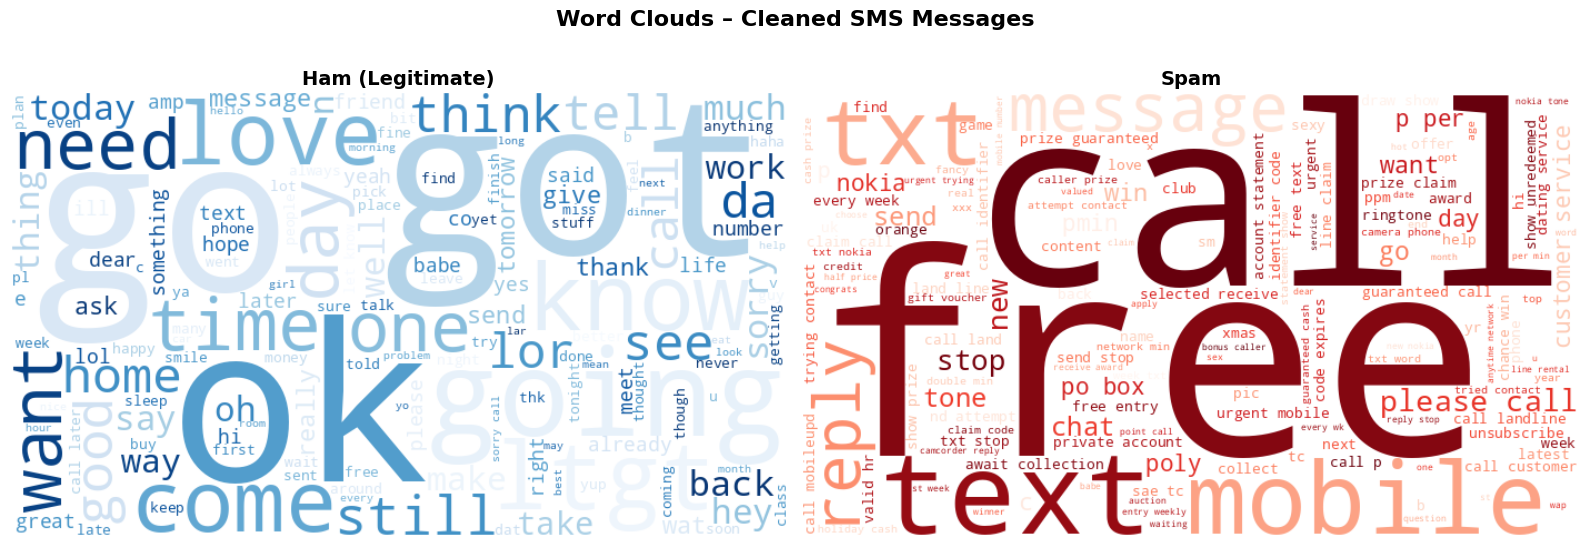

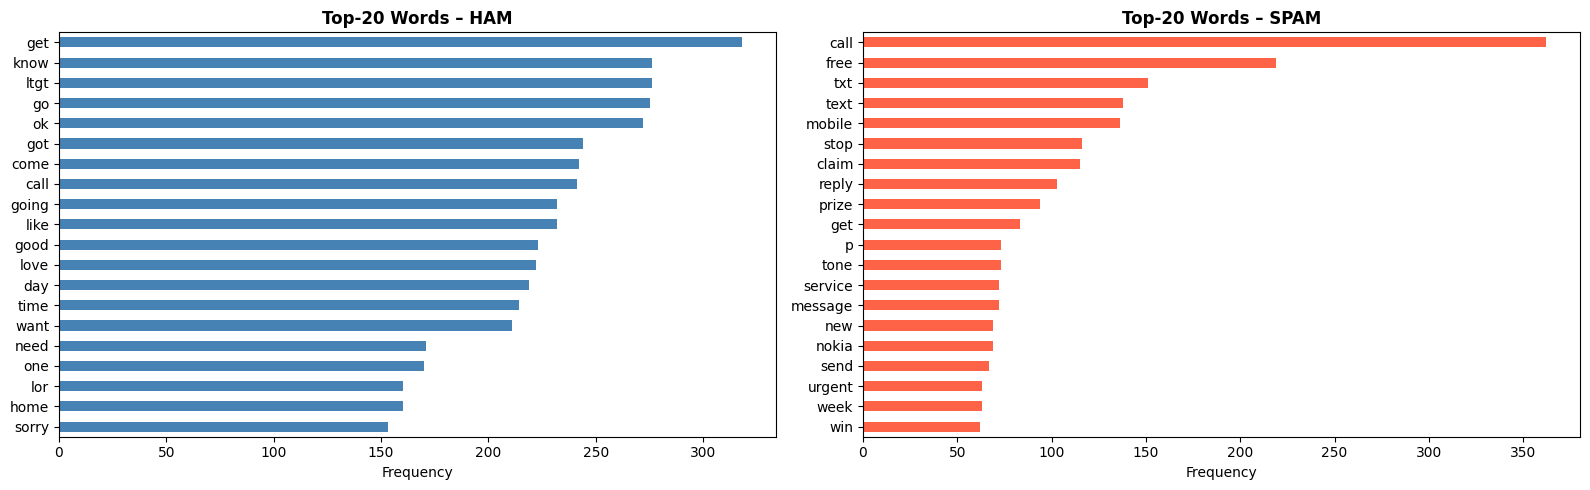

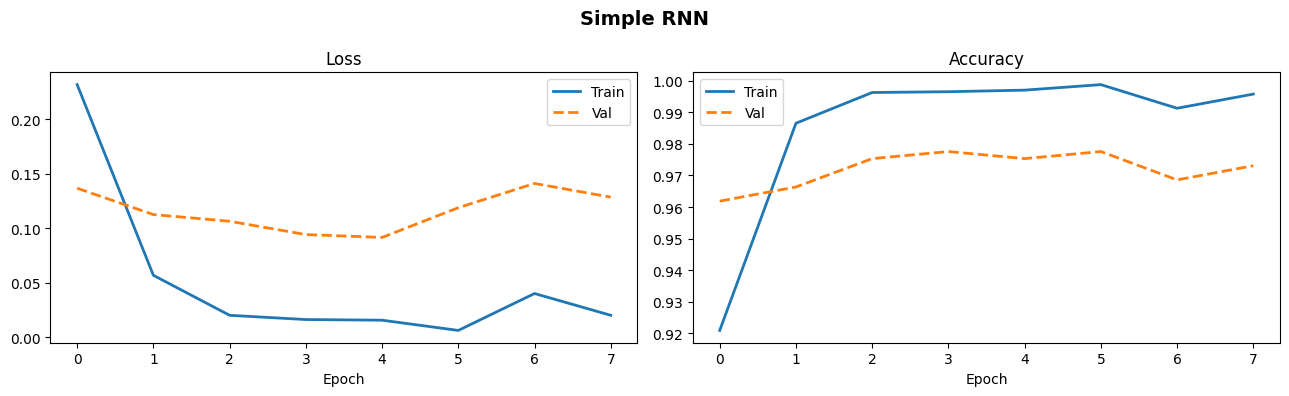

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("Simple RNN", fontsize=14, fontweight="bold")

ax1.plot(hist1.history["loss"],      label="Train", lw=2)
ax1.plot(hist1.history["val_loss"],  label="Val",   lw=2, ls="--")
ax1.set_title("Loss"); ax1.set_xlabel("Epoch"); ax1.legend()

ax2.plot(hist1.history["accuracy"],     label="Train", lw=2)
ax2.plot(hist1.history["val_accuracy"], label="Val",   lw=2, ls="--")
ax2.set_title("Accuracy"); ax2.set_xlabel("Epoch"); ax2.legend()

plt.tight_layout()
plt.show()

LSTM Trainable Emb

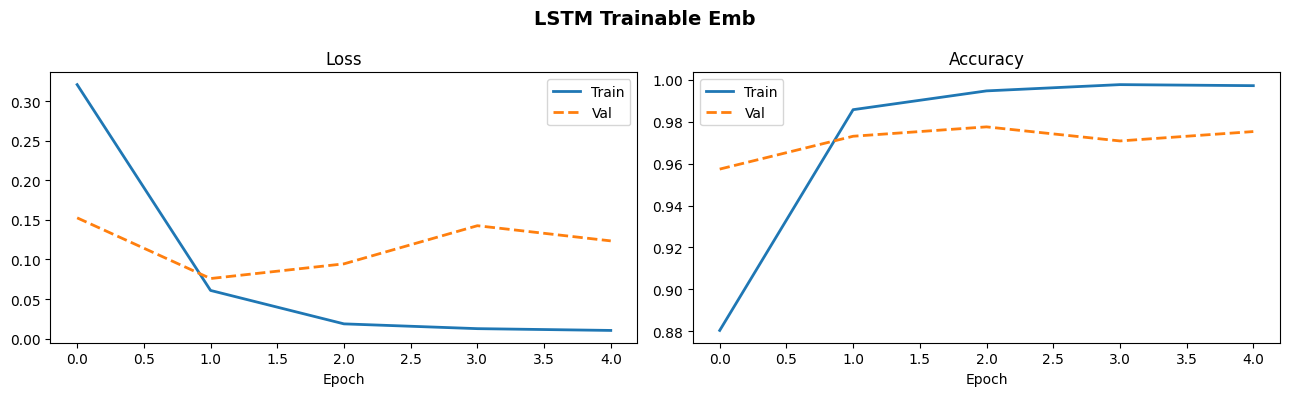

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("LSTM Trainable Emb", fontsize=14, fontweight="bold")

ax1.plot(hist2.history["loss"],      label="Train", lw=2)
ax1.plot(hist2.history["val_loss"],  label="Val",   lw=2, ls="--")
ax1.set_title("Loss"); ax1.set_xlabel("Epoch"); ax1.legend()

ax2.plot(hist2.history["accuracy"],     label="Train", lw=2)
ax2.plot(hist2.history["val_accuracy"], label="Val",   lw=2, ls="--")
ax2.set_title("Accuracy"); ax2.set_xlabel("Epoch"); ax2.legend()

plt.tight_layout()
plt.show()

LSTM Word2Vec Emb

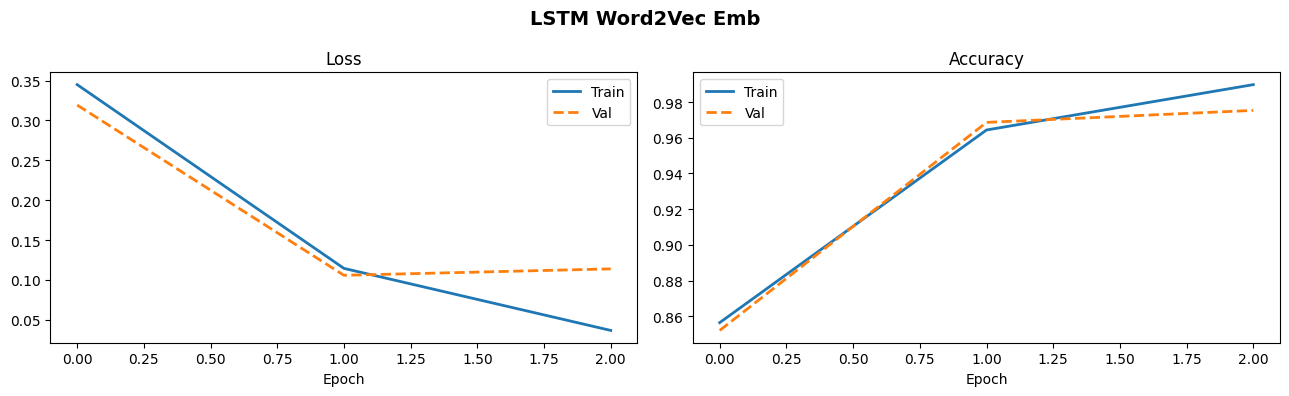

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("LSTM Word2Vec Emb", fontsize=14, fontweight="bold")

ax1.plot(hist3.history["loss"],      label="Train", lw=2)
ax1.plot(hist3.history["val_loss"],  label="Val",   lw=2, ls="--")
ax1.set_title("Loss"); ax1.set_xlabel("Epoch"); ax1.legend()

ax2.plot(hist3.history["accuracy"],     label="Train", lw=2)
ax2.plot(hist3.history["val_accuracy"], label="Val",   lw=2, ls="--")
ax2.set_title("Accuracy"); ax2.set_xlabel("Epoch"); ax2.legend()

plt.tight_layout()
plt.show()

Evalaute each model

Simple RNN

Simple RNN

  Accuracy: 0.9749
              precision    recall  f1-score   support

         Ham       0.98      0.99      0.99       966
        Spam       0.94      0.87      0.90       149

    accuracy                           0.97      1115
   macro avg       0.96      0.93      0.94      1115
weighted avg       0.97      0.97      0.97      1115



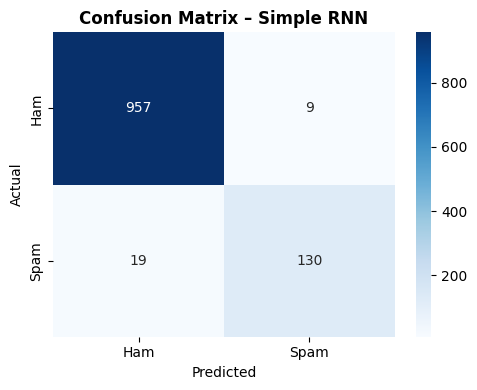

In [ ]:
probs1 = model1.predict(X_test_pad, verbose=0).flatten()
p1     = (probs1 >= 0.5).astype(int)
acc1   = accuracy_score(y_test, p1)

print(f"Simple RNN\n")
print(f"  Accuracy: {acc1:.4f}")
print(classification_report(y_test, p1, target_names=["Ham", "Spam"]))

cm1 = confusion_matrix(y_test, p1)
plt.figure(figsize=(5, 4))
sns.heatmap(cm1, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Ham", "Spam"],
            yticklabels=["Ham", "Spam"])
plt.title("Confusion Matrix – Simple RNN", fontweight="bold")
plt.ylabel("Actual"); plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

LSTM Trainable Emb

LSTM Trainable Emb

  Accuracy: 0.9785
              precision    recall  f1-score   support

         Ham       0.98      1.00      0.99       966
        Spam       0.99      0.85      0.91       149

    accuracy                           0.98      1115
   macro avg       0.98      0.92      0.95      1115
weighted avg       0.98      0.98      0.98      1115



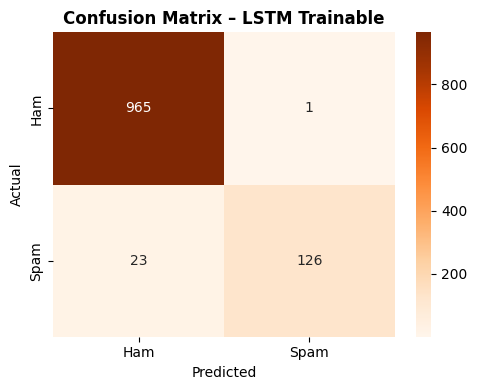

In [ ]:
probs2 = model2.predict(X_test_pad, verbose=0).flatten()
p2     = (probs2 >= 0.5).astype(int)
acc2   = accuracy_score(y_test, p2)

print(f"LSTM Trainable Emb\n")
print(f"  Accuracy: {acc2:.4f}")
print(classification_report(y_test, p2, target_names=["Ham", "Spam"]))

cm2 = confusion_matrix(y_test, p2)
plt.figure(figsize=(5, 4))
sns.heatmap(cm2, annot=True, fmt="d", cmap="Oranges",
            xticklabels=["Ham", "Spam"],
            yticklabels=["Ham", "Spam"])
plt.title("Confusion Matrix – LSTM Trainable", fontweight="bold")
plt.ylabel("Actual"); plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

LSTM Word2Vec

LSTM Word2Vec Emb

  Accuracy: 0.8726
              precision    recall  f1-score   support

         Ham       0.87      1.00      0.93       966
        Spam       1.00      0.05      0.09       149

    accuracy                           0.87      1115
   macro avg       0.94      0.52      0.51      1115
weighted avg       0.89      0.87      0.82      1115



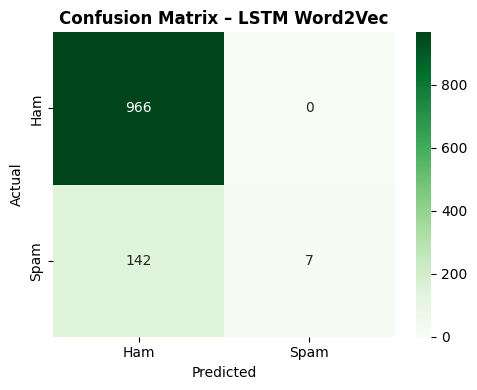

In [ ]:
probs3 = model3.predict(X_test_pad, verbose=0).flatten()
p3     = (probs3 >= 0.5).astype(int)
acc3   = accuracy_score(y_test, p3)

print(f"LSTM Word2Vec Emb\n")
print(f"  Accuracy: {acc3:.4f}")
print(classification_report(y_test, p3, target_names=["Ham", "Spam"]))

cm3 = confusion_matrix(y_test, p3)
plt.figure(figsize=(5, 4))
sns.heatmap(cm3, annot=True, fmt="d", cmap="Greens",
            xticklabels=["Ham", "Spam"],
            yticklabels=["Ham", "Spam"])
plt.title("Confusion Matrix – LSTM Word2Vec", fontweight="bold")
plt.ylabel("Actual"); plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

Comparision

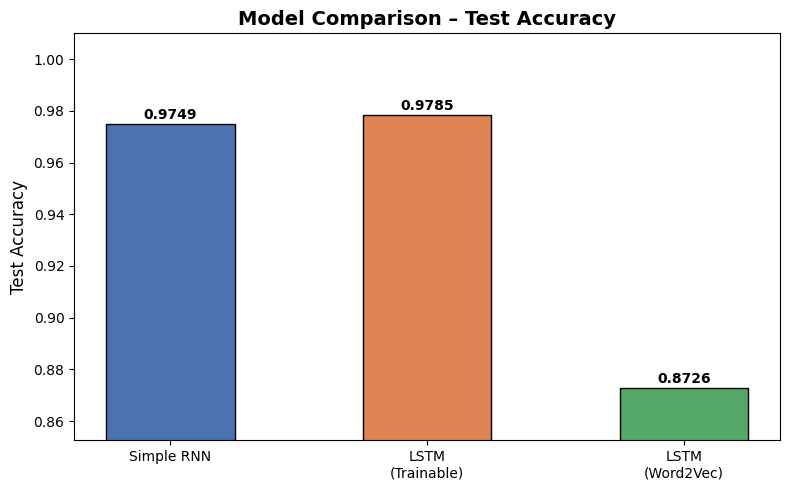

In [ ]:
model_names = ["Simple RNN", "LSTM\n(Trainable)", "LSTM\n(Word2Vec)"]
accuracies  = [acc1, acc2, acc3]

plt.figure(figsize=(8, 5))
bars = plt.bar(model_names, accuracies,
               color=["#4C72B0", "#DD8452", "#55A868"],
               edgecolor="black", width=0.5)
plt.ylim(min(accuracies) - 0.02, 1.01)
plt.ylabel("Test Accuracy", fontsize=12)
plt.title("Model Comparison – Test Accuracy", fontsize=14, fontweight="bold")
for bar, val in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.002,
             f"{val:.4f}", ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

Error Analysis

In [ ]:
misclassified = np.where(p3 != y_test)[0]
print(f"\nTotal misclassified samples: {len(misclassified)}")

print("\n--- 3 Misclassified Examples ---")
reasons = {
    "spam→ham": "Short spam message with no explicit spam keywords; the model lacked "
                "enough signal to flag it as spam.",
    "ham→spam": "Ham message contains promotional words (e.g. 'free', 'win') that "
                "strongly correlate with spam in the training data.",
}
for i, idx in enumerate(misclassified[:3]):
    actual    = "spam" if y_test[idx] == 1 else "ham"
    predicted = "spam" if p3[idx]    == 1 else "ham"
    direction = f"{actual}→{predicted}"
    reason    = reasons.get(direction, "Ambiguous language confuses the model.")
    print(f"\n  Example {i+1}")
    print(f"    Raw text   : {X_test[idx][:120]}")
    print(f"    Actual     : {actual.upper()}")
    print(f"    Predicted  : {predicted.upper()}")
    print(f"    Reason     : {reason}")


Total misclassified samples: 142

--- 3 Misclassified Examples ---

  Example 1
    Raw text   : cash prize claim call
    Actual     : SPAM
    Predicted  : HAM
    Reason     : Short spam message with no explicit spam keywords; the model lacked enough signal to flag it as spam.

  Example 2
    Raw text   : unsubscribed service get ton sexy babe hunk straight phone go subscription
    Actual     : SPAM
    Predicted  : HAM
    Reason     : Short spam message with no explicit spam keywords; the model lacked enough signal to flag it as spam.

  Example 3
    Raw text   : want get laid nite want real dogging location sent direct mobile join uk largest dogging network txt park nyt eca lp mes
    Actual     : SPAM
    Predicted  : HAM
    Reason     : Short spam message with no explicit spam keywords; the model lacked enough signal to flag it as spam.


Save Artifacts for GUI

In [ ]:
import pickle

model3.save("best_model.keras")

with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

with open("config.pkl", "wb") as f:
    pickle.dump({"MAX_LEN": MAX_LEN, "THRESHOLD": 0.5}, f)

print("Model saved successfully!")

Model saved successfully!


4.5.5 Streamlit GUI

In [ ]:
!pkill -f streamlit
!streamlit run sms_app.py > logs.txt 2>&1 &

import time
time.sleep(3)

In [ ]:
from pyngrok import ngrok
from google.colab import userdata

In [ ]:
!pip install streamlit -q

In [ ]:
%%writefile sms_app.py
import re, pickle
import numpy as np
import streamlit as st
import tensorflow as tf
from tensorflow.keras.preprocessing.sequence import pad_sequences
import nltk, contractions
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Ensure resources are downloaded
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

@st.cache_resource
def load_artifacts():
    model = tf.keras.models.load_model('best_model.keras')
    with open('tokenizer.pkl', 'rb') as f:
        tokenizer = pickle.load(f)
    with open('config.pkl', 'rb') as f:
        cfg = pickle.load(f)
    return model, tokenizer, cfg['MAX_LEN'], cfg['THRESHOLD']

try:
    model, tokenizer, MAX_LEN, THRESHOLD = load_artifacts()
except Exception as e:
    st.error(f'Error loading model: {e}')

STOP_WORDS = set(stopwords.words('english'))
LEMMATIZER = WordNetLemmatizer()

def clean_text(text):
    text = contractions.fix(text)
    text = text.lower()
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = text.split()
    tokens = [LEMMATIZER.lemmatize(w) for w in tokens if w not in STOP_WORDS]
    return ' '.join(tokens)

def predict(text):
    cleaned = clean_text(text)
    seq = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(seq, maxlen=MAX_LEN, padding='post', truncating='post')
    prob = float(model.predict(padded, verbose=0)[0][0])
    return prob, cleaned

st.title('SMS Spam Detector')
sms = st.text_area('Enter SMS message here:', height=150)

if st.button('Classify'):
    if sms.strip():
        prob, cleaned = predict(sms)
        label = 'SPAM' if prob >= THRESHOLD else 'HAM'
        st.subheader(f'Result: {label}')
        st.write(f'Confidence: {prob:.2%}')
    else:
        st.warning('Please enter text.')

Overwriting sms_app.py


In [ ]:
!npm install -g localtunnel

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦
added 22 packages in 5s
⠦
⠦3 packages are looking for funding
⠦  run `npm fund` for details
⠦

In [ ]:
!pkill -f streamlit

In [ ]:
!streamlit run sms_app.py &>/dev/null &
import time
time.sleep(3)
print("Streamlit started!")

Streamlit started!


In [ ]:
!curl -s ifconfig.me

34.126.109.224

In [ ]:
!pip install pyngrok -q
from pyngrok import ngrok

In [ ]:
import streamlit as st

# Page Config
st.set_page_config(
    page_title="SMS Spam Detector",

    layout="centered"
)

# Custom CSS
st.markdown("""
<style>
.main {
    background-color: #f5f7fa;
}
.title {
    text-align: center;
    font-size: 42px;
    font-weight: bold;
    color: #1f77b4;
}
.subtitle {
    text-align: center;
    color: gray;
    margin-bottom: 30px;
}
.stButton>button {
    width: 100%;
    border-radius: 10px;
    height: 50px;
    font-size: 18px;
}
.result-box {
    padding: 20px;
    border-radius: 12px;
    font-size: 20px;
    text-align: center;
    margin-top: 20px;
}
</style>
""", unsafe_allow_html=True)

# Title
st.markdown('<p class="title">SMS Spam Detector</p>', unsafe_allow_html=True)
st.markdown('<p class="subtitle">Detect whether a message is Spam or Ham</p>', unsafe_allow_html=True)

# Input Box
message = st.text_area(
    "Enter your SMS message below:",
    height=180,
    placeholder="Type your message here..."
)

# Predict Button
if st.button("Analyze Message"):

    if message.strip() == "":
        st.warning("Please enter a message first.")
    else:

        # Dummy prediction logic
        # Replace this with your ML model
        if "win" in message.lower() or "free" in message.lower():
            prediction = "SPAM 🚨"
            color = "#ffdddd"
        else:
            prediction = "HAM ✅"
            color = "#ddffdd"

        st.markdown(
            f"""
            <div class="result-box" style="background-color:{color};">
                Prediction: <b>{prediction}</b>
            </div>
            """,
            unsafe_allow_html=True
        )

# Footer
st.markdown("---")
st.caption("Built with Streamlit + Ngrok")

Error during deployment: Secret NGROK_AUTH_TOKEN does not exist.


#Save in the Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import shutil

# Save all important files to Drive
shutil.copy("best_model.keras", "/content/drive/MyDrive/best_model.keras")
shutil.copy("tokenizer.pkl",    "/content/drive/MyDrive/tokenizer.pkl")
shutil.copy("config.pkl",       "/content/drive/MyDrive/config.pkl")
shutil.copy("sms_app.py",       "/content/drive/MyDrive/sms_app.py")

print("All files saved to Google Drive!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
All files saved to Google Drive!


Run this during viva

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import shutil
shutil.copy("/content/drive/MyDrive/best_model.keras", "best_model.keras")
shutil.copy("/content/drive/MyDrive/tokenizer.pkl",    "tokenizer.pkl")
shutil.copy("/content/drive/MyDrive/config.pkl",       "config.pkl")
shutil.copy("/content/drive/MyDrive/sms_app.py",       "sms_app.py")

print("Files restored!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Files restored!


In [ ]:
!pip install streamlit pyngrok contractions wordcloud gensim -q

In [ ]:
print("--- Streamlit App Logs ---")
!cat logs.txt

--- Streamlit App Logs ---
cat: logs.txt: No such file or directory


In [ ]:
from pyngrok import ngrok

ngrok.set_auth_token("3DUurXMkwrGpdv1MBQjnBYElabK_87R5Zt3C7tHtq5BpA1pYV")

public_url = ngrok.connect(8501)

print(public_url)

NgrokTunnel: "https://unretired-deflector-pettiness.ngrok-free.dev" -> "http://localhost:8501"


In [ ]:
!cat logs.txt



2026-05-09 17:34:52.069 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.126.109.224:8501

